# The discount, split by segment

**Week 1, Thursday. Chapter 4 of 6.** By the end of this notebook you can reproduce a campaign's
headline lift, split it by segment, say why the blend and the segments disagree, and say what
putting both groups on one mix checks and what it cannot.

> **The client asks.** "Marketing ran a monsoon-sale discount for Retail-Plus in August, says it
> lifted revenue 6 percent, and wants to repeat it for Diwali. Did the discount work, or did those
> customers buy anyway?"
>
> Meera Raghavan, CEO, Kalpa Retail, with the marketing lead's report open beside her

**The metric at stake.** August spend per customer, for customers who got the sale against
customers who did not. **Who asks and what rides on it.** The marketing lead owns the campaign and
wants it repeated at 15 percent off; Meera signs the Diwali budget. Monday's rule applies: at 15
percent off, orders must rise about 17.6 percent just for revenue to stand still, so a sale that
did not lift spend gives margin away. **Who else faces it.** eBay measured its search ads in large
controlled experiments and split the result by customer (Blake, Nosko and Tadelis, NBER working
paper 20171). New and infrequent users bought more after seeing an ad; frequent users, whose buying
the ads did not change, took most of the ad spend, so the average return was negative. The classic
public case of a blend reversing is UC Berkeley's 1973 graduate admissions: 44 percent of men and 35
percent of women were admitted overall, and department by department the small bias ran in favour
of women.

Chapters 1 to 3 answered Meera's first two questions. This chapter opens the campaigns table and
the exposure table, and adds `spend` and `group` to the toolkit.

**Where the exposure table comes from.** The exposure table is the campaign platform's August
list: the 160 Retail-Plus and Retail-Core customers the platform held, under the platform's own
customer ids, with one average August spend for each group. It records who received the sale,
whatever the sale was aimed at, which is why it counts Retail-Core customers among them although the
campaigns table aimed the sale at Retail-Plus: the campaigns table is the plan, and the list is what
the platform sent. It cannot be matched to Finance's order file, whose 22 Retail-Plus members and
discount column carry no record of the sale. So read it for who got the sale and how the two groups
differ. The Diwali hold-back is sized on the platform's list, and the retention offer on Finance's
order file.

**Setup.** The toolkit so far, plus the two campaign tables and two new helpers.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import itertools
import random
import statistics

ORDERS = kit.load_csv("C2_W01_D04_orders_STUDENT.csv")
SEGMENTS = ["Retail-Core", "Retail-Plus", "Student", "Business"]


def mean(values):
    return sum(values) / len(values)


def member_totals(segment, quarter):
    """Delivered revenue per member of one segment in one quarter, members always in the same order."""
    members = sorted({o["customer_id"] for o in ORDERS if o["segment"] == segment})
    totals = {m: 0 for m in members}
    for o in ORDERS:
        if o["segment"] == segment and o["quarter"] == quarter and o["status"] == "delivered":
            totals[o["customer_id"]] += int(o["amount"])
    return [totals[m] for m in members]


def flip_gaps(q1, q2, times, seed):
    """The same members measured twice: a coin per member decides which of its two quarters is Q1."""
    random.seed(seed)                              # the same coins on every laptop
    diffs = [a - b for a, b in zip(q1, q2)]        # each member's own Q1 less Q2
    gaps = []
    for _ in range(times):
        flipped = [d if random.random() < 0.5 else -d for d in diffs]   # heads keeps, tails swaps
        gaps.append(mean(flipped))
    return gaps


def shuffle_gaps(q1, q2, times, seed):
    """Two groups of different customers: deal every value to two piles at random, many times."""
    random.seed(seed)
    pool = q1 + q2                                 # all the values, labels ignored
    gaps = []
    for _ in range(times):
        random.shuffle(pool)                       # deal at random
        gaps.append(mean(pool[:len(q1)]) - mean(pool[len(q1):]))
    return gaps


def share_at_least(gaps, real):
    """Counting one direction: the share of chance-only worlds with a gap at least as large as the real one."""
    return sum(1 for g in gaps if g >= real) / len(gaps)


def share_either(gaps, real):
    """Counting either direction: the share of chance-only worlds with a gap that large, up or down."""
    return sum(1 for g in gaps if abs(g) >= abs(real)) / len(gaps)


def delivered(segment, quarter):
    """A segment's delivered revenue in one quarter, in rupees."""
    return sum(int(o["amount"]) for o in ORDERS
               if o["segment"] == segment and o["quarter"] == quarter and o["status"] == "delivered")


def bootstrap_gaps(q1, q2, times, seed):
    """The same members twice: redraw the members' own Q1 less Q2 differences with replacement."""
    random.seed(seed)
    diffs = [a - b for a, b in zip(q1, q2)]
    return [mean([random.choice(diffs) for _ in diffs]) for _ in range(times)]


def orders_in(segment, quarter):
    return sum(1 for o in ORDERS if o["segment"] == segment and o["quarter"] == quarter)


def flip_rises(n_orders, times, seed):
    """Deal each of n orders to Q1 or Q2 by a fair coin, many times, and keep each rise."""
    random.seed(seed)
    rises = []
    for _ in range(times):
        q2 = sum(1 for _ in range(n_orders) if random.random() < 0.5)
        q1 = n_orders - q2
        rises.append(float("inf") if q1 == 0 else q2 / q1 - 1)
    return rises


EXPOSURE = kit.load_csv("C2_W01_D04_exposure_STUDENT.csv")
CAMPAIGNS = kit.load_csv("C2_W01_D04_campaigns_STUDENT.csv")


def spend(rows):
    """August spend per customer across a list of exposure rows."""
    return mean([int(r["august_revenue"]) for r in rows])


def group(flag, segment=None):
    """The exposure rows for one group, exposed "yes" or "no", optionally inside one segment."""
    return [r for r in EXPOSURE if r["exposed"] == flag and (segment is None or r["segment"] == segment)]

print(len(EXPOSURE), "customers on the platform's list;", CAMPAIGNS[0]["name"], CAMPAIGNS[0]["discount_pct"],
      "percent off,", CAMPAIGNS[0]["starts"], "to", CAMPAIGNS[0]["ends"], "; target", CAMPAIGNS[0]["target_segment"])

160 customers on the platform's list; Monsoon Sale 15 percent off, 2026-08-05 to 2026-08-19 ; target Retail-Plus


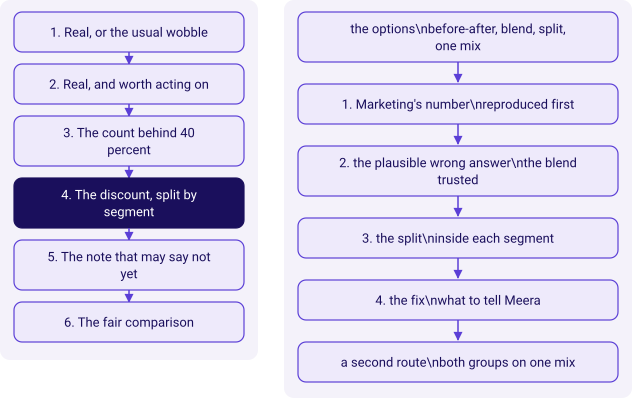

In [2]:
kit.side_by_side(
    kit.ladder(['Real, or the usual wobble', 'Real, and worth acting on', 'The count behind 40 percent', 'The discount, split by segment', 'The note that may say not yet', 'The fair comparison'], lit=3, show=False),
    kit.vflow(['the options\\nbefore-after, blend, split, one mix', "1. Marketing's number\\nreproduced first", '2. the plausible wrong answer\\nthe blend trusted', '3. the split\\ninside each segment', '4. the fix\\nwhat to tell Meera', 'a second route\\nboth groups on one mix'], show=False),
)

## The options

Four ways a team could answer "did the discount work?". They differ in which list they stand on and
in what each takes on trust, so the sizing cell measures those.

| Option | What it compares | What it risks |
|---|---|---|
| A. Before and after | The targeted segment's revenue in the sale month against the month before, in Finance's order file | Everything else that changed that month |
| B. Exposed against not exposed, blended | August spend for everyone who got the sale against everyone who did not, on the platform's list | Two groups built from different mixes of customers |
| C. Exposed against not exposed, inside each segment | The same comparison run separately in each segment | Anything that differs between the groups inside a segment |
| D. Both groups on one mix | Each group's segment averages weighted to the same mix of segments | The same as C; it is C said as one number |

Option,What it stands on,What it assumes,What it risks
A. Before and after,Finance's order file: 13 Retail-Plus orders in July and August,nothing else changed between the months,credits the sale with the month
B. Blended,the platform's list: 160 customers in 2 groups,both groups hold the same mix of customers,the mixes differ: 50% against 40% Retail-Plus
C. Inside each segment,the platform's list: 160 customers in 4 cells,who got it inside a segment was as good as random,whatever else differs inside a segment
D. Both groups on one mix,"the same 4 cells, reweighted",the same as C,nothing beyond C: it agrees with C by construction


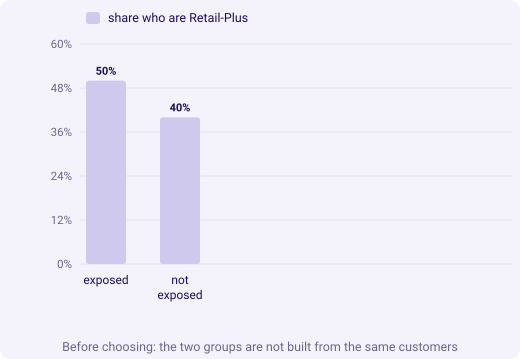

at 15 percent off, orders must rise 17.6% for revenue to stand still


In [3]:
mix_yes = len(group("yes", "Retail-Plus")) / len(group("yes"))
mix_no = len(group("no", "Retail-Plus")) / len(group("no"))
stand_still = 1 / (1 - int(CAMPAIGNS[0]["discount_pct"]) / 100) - 1
july_august = sum(1 for o in ORDERS if o["segment"] == "Retail-Plus" and o["status"] == "delivered"
                  and o["order_date"][:7] in ("2026-07", "2026-08"))
rows = [
    ("A. Before and after", f"Finance's order file: {july_august} Retail-Plus orders in July and August",
     "nothing else changed between the months", "credits the sale with the month"),
    ("B. Blended", f"the platform's list: {len(EXPOSURE)} customers in 2 groups",
     "both groups hold the same mix of customers", f"the mixes differ: {mix_yes:.0%} against {mix_no:.0%} Retail-Plus"),
    ("C. Inside each segment", f"the platform's list: {len(EXPOSURE)} customers in 4 cells",
     "who got it inside a segment was as good as random", "whatever else differs inside a segment"),
    ("D. Both groups on one mix", "the same 4 cells, reweighted", "the same as C",
     "nothing beyond C: it agrees with C by construction"),
]
kit.table(["Option", "What it stands on", "What it assumes", "What it risks"], rows,
          caption="The options sized on Kalpa's files by what separates them")
kit.columns(["exposed", "not exposed"], [("share who are Retail-Plus", [round(100 * mix_yes), round(100 * mix_no)])],
            fmt=lambda v: f"{v:.0f}%", width=520, title="Before choosing: the two groups are not built from the same customers")
print(f"at {CAMPAIGNS[0]['discount_pct']} percent off, orders must rise {stand_still:.1%} for revenue to stand still")
kit.check("the two groups differ in mix", abs(mix_yes - mix_no) > 0.05, f"{mix_yes:.0%} against {mix_no:.0%}")
kit.check("Monday's rule: 15 percent off needs about 17.6 percent more volume", round(stand_still, 3) == 0.176)

**The best-fit call: C, with D as its one-line form.** The two groups hold different mixes of
customers, which the chart above shows before any spend is compared, so the blend in B compares
Retail-Plus-heavy against Retail-Core-heavy as much as sale against no sale. C compares like with
like inside each segment. A comes back in chapter 6, where the question is what else changed in
August. **The fact that would change the call.** A group chosen at random: if Marketing had decided
who got the sale by coin flip, the two groups would share one mix and B would be fair.

## 1. Marketing's number, reproduced first

Before disagreeing with anyone's number, rebuild it. Marketing compared everyone who got the sale
with everyone who did not.

**Predict before you run.** Marketing's lift will come out at: a) about 6 percent, as reported;
b) about 3 percent; c) negative; d) impossible to reproduce from these tables.

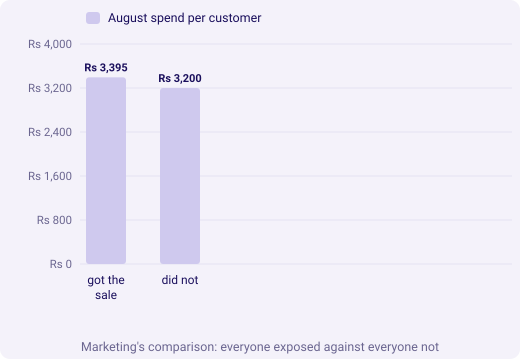

exposed Rs 3,395 against Rs 3,200: +6.1%


In [4]:
blend_yes, blend_no = spend(group("yes")), spend(group("no"))
blend = blend_yes / blend_no - 1
kit.columns(["got the sale", "did not"], [("August spend per customer", [round(blend_yes), round(blend_no)])],
            fmt=kit.rupees, width=520, title="Marketing's comparison: everyone exposed against everyone not")
print(f"exposed {kit.rupees(blend_yes)} against {kit.rupees(blend_no)}: {blend:+.1%}")
kit.check("Marketing's 6 percent reproduces from the tables", 0.05 < blend < 0.07, f"{blend:+.1%}")

**What happened.** The answer is a. Customers who got the sale spent Rs 3,395 in August against
Rs 3,200 for those who did not, a lift of 6.1 percent. Marketing's arithmetic is right, which is why
the next step matters.

## 2. The plausible wrong answer

**The plausible wrong answer.** The draft trusts the reproduced number and writes the plan.

In [5]:
draft = (f"The discount worked: exposed customers spent {kit.rupees(blend_yes)} against {kit.rupees(blend_no)}, "
         f"up {blend:.1%}; repeat it for Diwali.")
print(draft)

The discount worked: exposed customers spent Rs 3,395 against Rs 3,200, up 6.1%; repeat it for Diwali.


**Why it is wrong.** The comparison is correct arithmetic on an unfair pair of groups. The exposed
group holds more Retail-Plus members, who spend more whatever happens, so part or all of the 6.1
percent could be who got the sale rather than what the sale did. If the draft goes to Meera, a
Diwali sale at 15 percent off is repeated on a lift that may not exist, and it needs 17.6 percent
more orders just to stand still.

## 3. The check: split by segment

Run the same comparison inside each segment, where the customers are alike.

**Predict before you run.** Inside Retail-Plus and inside Retail-Core, customers who got the sale
spent: a) more, by about 6 percent in each; b) more in one segment and less in the other; c) less in
both; d) the same in both.

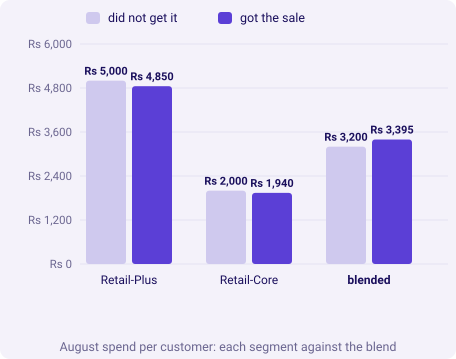

Segment,Did not get it,Got the sale,Change,"Customers, not / got"
Retail-Plus,"Rs 5,000","Rs 4,850",-3.0%,40 / 30
Retail-Core,"Rs 2,000","Rs 1,940",-3.0%,60 / 30


In [6]:
cells = {}
for s in ["Retail-Plus", "Retail-Core"]:
    cells[s] = (spend(group("no", s)), spend(group("yes", s)), len(group("no", s)), len(group("yes", s)))
kit.columns(["Retail-Plus", "Retail-Core", "blended"],
            [("did not get it", [round(cells["Retail-Plus"][0]), round(cells["Retail-Core"][0]), round(blend_no)]),
             ("got the sale", [round(cells["Retail-Plus"][1]), round(cells["Retail-Core"][1]), round(blend_yes)])],
            fmt=kit.rupees, lit=[2], title="August spend per customer: each segment against the blend")
kit.table(["Segment", "Did not get it", "Got the sale", "Change", "Customers, not / got"],
          [(s, kit.rupees(a), kit.rupees(b), f"{b / a - 1:+.1%}", f"{n} / {m}") for s, (a, b, n, m) in cells.items()],
          caption="The same comparison inside each segment, with the count behind every average")
within = {s: b / a - 1 for s, (a, b, _, _) in cells.items()}
kit.check("inside every segment the exposed spent less", all(v < 0 for v in within.values()), f"{within}")
kit.check("the blend rises while the segments fall", blend > 0 and max(within.values()) < 0)

**What happened.** The answer is c. Inside Retail-Plus the customers who got the sale spent Rs
4,850 against Rs 5,000, and inside Retail-Core Rs 1,940 against Rs 2,000: about 3 percent less in
both. The blend rose because half of the exposed group were Retail-Plus members against 40 percent
of the others, and Retail-Plus members spend more than twice as much. Each segment says one thing
and the blend says the opposite; the segments are the fair comparison.

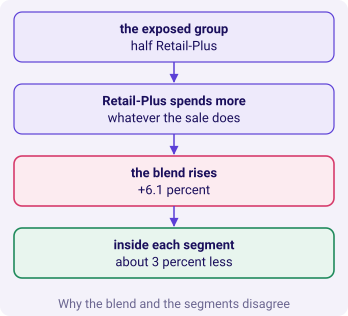

In [7]:
kit.vflow(["the exposed group\nhalf Retail-Plus", "Retail-Plus spends more\nwhatever the sale does",
           "the blend rises\n+6.1 percent", "inside each segment\nabout 3 percent less"],
          kinds=["plain", "plain", "bad", "good"], title="Why the blend and the segments disagree")

## 4. The fix: what to tell Meera

"The monsoon sale did not lift spend: inside each segment, customers who got it spent about 3
percent less than customers who did not, on 30 exposed and 40 or 60 unexposed customers per segment.
Marketing's 6 percent comes from who got the sale, since the exposed group held more Retail-Plus
members. Do not repeat it as designed; if Diwali runs a sale, hold back a random slice of each
segment so the comparison is fair." What changed: the decision, from repeat to redesign. The reason
is the mix of customers; Marketing's arithmetic was right.

## A second route: both groups on one mix, and what it checks

Put the exposed group's segment averages into the unexposed group's mix, and the other way round.
This route reuses the four cells the split used, so it cannot disagree with the split and cannot
catch an error in those cells. What it checks is the explanation: if the mix of customers is the
whole reason the blend rose, putting both groups on one mix must remove the whole 6.1 percent, both
ways round. The independent check comes in chapter 6, from Finance's order file.

**Predict before you run.** Reweighted to one mix, the exposed group's spend against the unexposed
group's will be: a) about 6 percent higher, as Marketing said; b) about 3 percent lower in both
directions; c) higher one way and lower the other; d) equal.

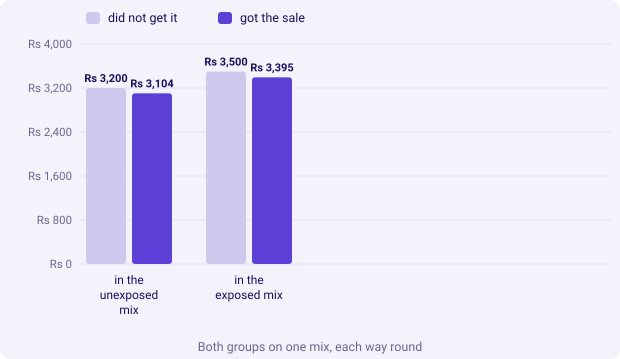

unexposed mix: Rs 3,104 against Rs 3,200, -3.0%; exposed mix: Rs 3,395 against Rs 3,500, -3.0%


In [8]:
w_no = {s: len(group("no", s)) / len(group("no")) for s in cells}
w_yes = {s: len(group("yes", s)) / len(group("yes")) for s in cells}
yes_in_no_mix = sum(w_no[s] * cells[s][1] for s in cells)
no_in_yes_mix = sum(w_yes[s] * cells[s][0] for s in cells)
one = yes_in_no_mix / blend_no - 1
two = blend_yes / no_in_yes_mix - 1
kit.columns(["in the unexposed mix", "in the exposed mix"],
            [("did not get it", [round(blend_no), round(no_in_yes_mix)]), ("got the sale", [round(yes_in_no_mix), round(blend_yes)])],
            fmt=kit.rupees, width=620, title="Both groups on one mix, each way round")
print(f"unexposed mix: {kit.rupees(yes_in_no_mix)} against {kit.rupees(blend_no)}, {one:+.1%}; "
      f"exposed mix: {kit.rupees(blend_yes)} against {kit.rupees(no_in_yes_mix)}, {two:+.1%}")
kit.check("the mix accounts for the whole blended lift, both ways round", abs(one - two) < 0.005 and one < 0,
          f"{one:+.1%} and {two:+.1%}")

**What happened.** The answer is b. On the unexposed group's mix the exposed spend Rs 3,104 against
Rs 3,200; on the exposed group's mix, Rs 3,395 against Rs 3,500. Both are 3.0 percent less, as they
must be if the mix is the whole story: the 6.1 percent is gone once both groups share one mix.
**When to switch.** Split by segment when the stakeholder reads a table; put both groups on one mix
when the answer has to be one number on one line of the note, or when there are too many segments to
show.

> **Kavya's review.** "You rebuilt Marketing's number before disagreeing with it, which is what
> keeps Monday civil. The split says 3 percent less in both segments, one mix says the same by
> construction, and the reason is who got the sale. Now tell me what else changed in August,
> because neither of them can see that."

### In the interview

**[F] Revenue rose after a discount; did the campaign work, and what would you need to know?** "Who
got it and against whom. I would reproduce the claimed lift, then compare customers who got it with
customers who did not inside each segment, and check the mix of the two groups. If the segments
disagree with the total, the total is a mix effect. To know properly I would want a random held-back
group next time, agreed before the campaign."

**[F] The campaign lifted revenue overall but every segment fell; how, and which do you report?**
"The exposed group leaned toward high spenders, so the blend rose on mix while each segment did
worse. I report the segments, and name the mix as the reason the blend rose, so nobody thinks I
picked the flattering cut."

**[D] Before and after, the blend, the split or one mix: which do you use for a campaign readout,
and what would make the blend acceptable?** "The split, with one mix as the one-line version, said
plainly to be the split restated. Before and after sees every August effect, and the blend mixes
customers. The blend becomes fair only when a coin decided who got the campaign."

### Depth: how big a mix shift it takes

Keep the segment averages fixed and move only the share of Retail-Plus members in the exposed
group. The blend's lift is invented from there, since only the mix changes.

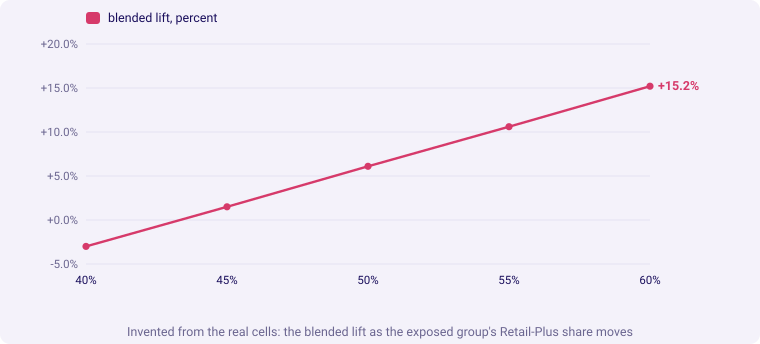

In [9]:
shares = [0.40, 0.45, 0.50, 0.55, 0.60]
lifts = []
for p in shares:
    mixed_yes = p * cells["Retail-Plus"][1] + (1 - p) * cells["Retail-Core"][1]
    lifts.append(round(100 * (mixed_yes / blend_no - 1), 1))
kit.line([f"{int(p * 100)}%" for p in shares], [("blended lift, percent", lifts, "bad")], lo=-5,
         fmt=lambda v: f"{v:+.1f}%", title="Invented from the real cells: the blended lift as the exposed group's Retail-Plus share moves")
kit.check("with the same mix as the unexposed group the blend shows the segments' fall", lifts[0] < 0, f"{lifts}")

In [10]:
kit.check_summary()
print("Next: chapter 5. Three answers, one page, and room for 'not yet'.")

Next: chapter 5. Three answers, one page, and room for 'not yet'.
